# Gene Expression copy number correction

June 11, 2024

## Goal:
Apply copy number correction to gene expression data

**Procedure:**
1. Load replication timing
2. Load gene expression data for all genes (may take a while, start with a smaller set)
4. Copy number correction
5. Store corrected data for deconvolution


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [91]:
from src.CopyNumberCorrection import CopyNumberCorrector

corrector = CopyNumberCorrector()
corrector.compute_replication_timing()

In [166]:
corrector.load_gene_expression_data(1)

In [172]:
corrector.correct_for_copy_number()

0/5578 - 00:00:00.003
1000/5578 - 00:00:00.579
2000/5578 - 00:00:01.141
3000/5578 - 00:00:01.706
4000/5578 - 00:00:02.284
5000/5578 - 00:00:02.861


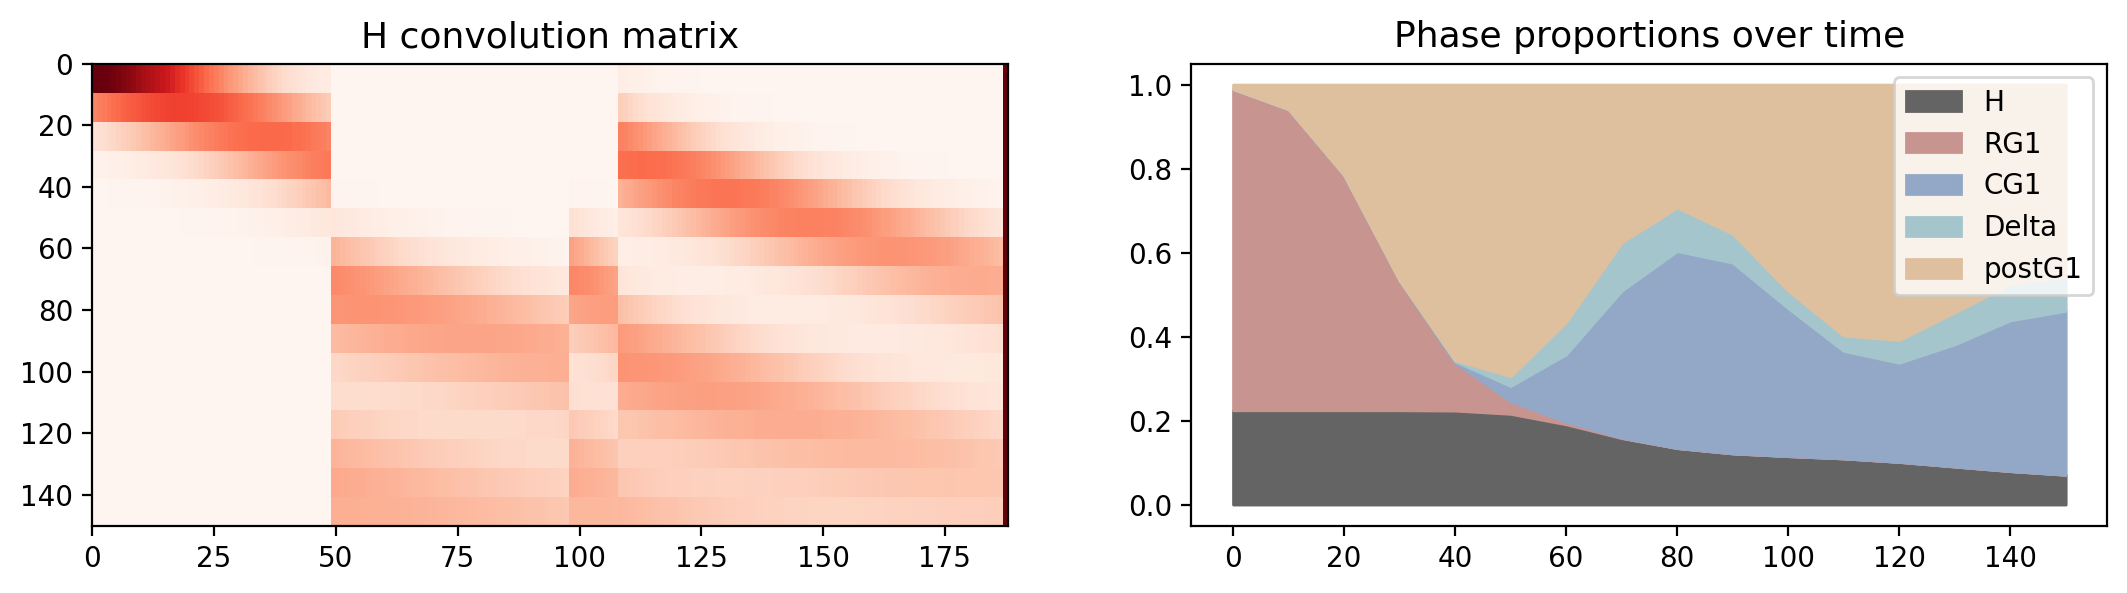

In [173]:
from src.delta_config import plot_H

plot_H(corrector.config, corrector.H)

In [174]:
corrector.compute_ptrs()

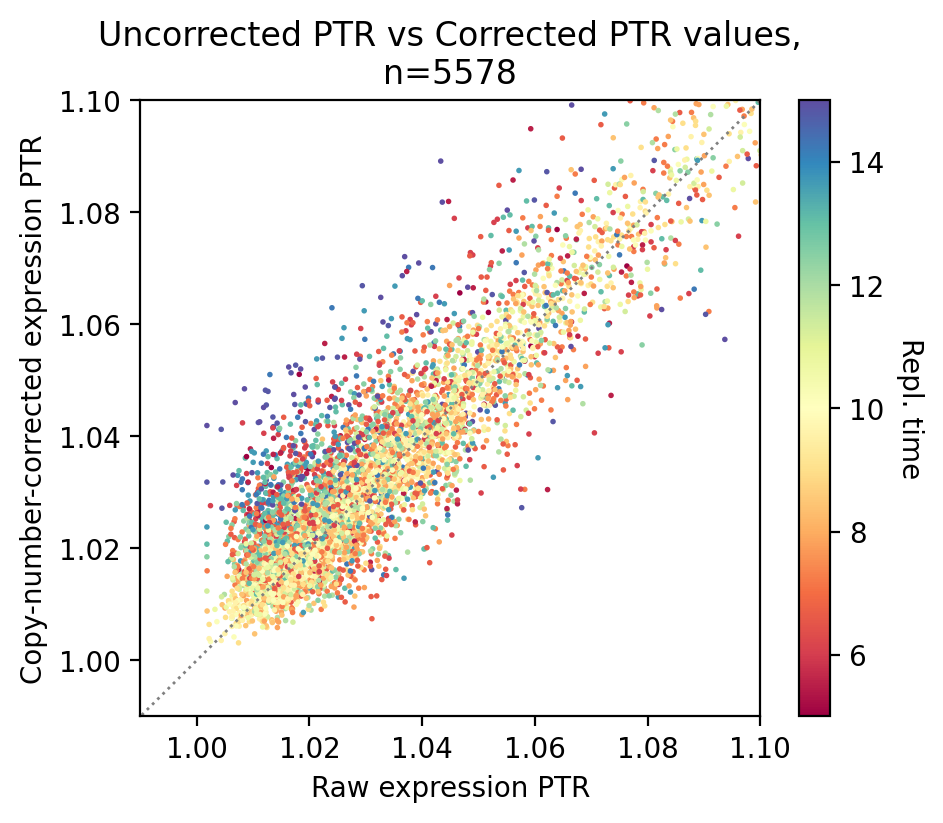

In [175]:
corrector.plot_ptrs()


In [176]:
corrector.ge_comparison_ptr_df.sort_values('difference')

,raw_ptr,corrected_ptr,difference,replication_time
orf_name,,,,
YJR030C,1.147064,1.103941,-0.043123,14.8086
YFL052W,1.147607,1.104768,-0.042839,13.0652
YDR258C,1.093707,1.057329,-0.036378,15.3898
YBR158W,1.140311,1.104922,-0.035389,15.3898
YDL105W,1.117949,1.082775,-0.035173,13.6463
...,...,...,...,...
YCR096C,1.001815,1.041948,0.040132,15.9710
YGR109C,1.297626,1.339524,0.041898,7.2535
YCR086W,1.075373,1.118236,0.042864,17.1333


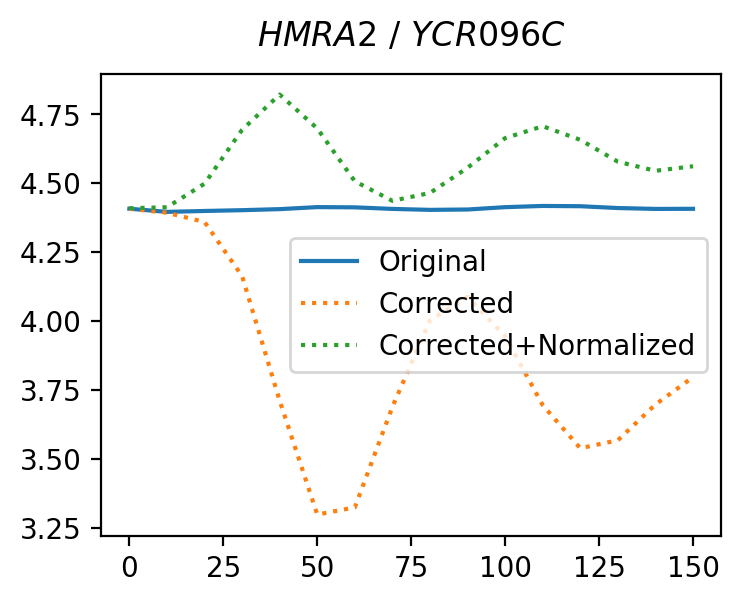

In [180]:
corrector.plot_corrected_gene('YCR096C')
